# Introduction
This notebook uses a Tanager orthorectified surface reflectance image to assess the landscape condition within the fire perimeter. At the time the image was collected, the Monroe Canyon Fire had grown to about 10 thousand acres in the 11 days since ignition. Multiple firefighting strategies were in operation, including dozers clearing fuel breaks and firefighters lighting additional strategic fires to consume fuels before the wildfire could add them to its momentum.

Due to the rapid growth and extreme fire behavior, areas of high burn severity are expected. This analysis aims to assess where within the current fire perimeter are major concentrations of ash (indicating higher burn severity), living green vegetation, and non-photosynthetic vegetation. Mapping ash concentrations will be especially helpful for determining ecological impacts and post fire hazard risk areas. 

In [1]:
import h5py
import requests
import sys
import numpy as np
import geopandas as gpd
import rasterio
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from mesma.core.mesma import MesmaCore, MesmaModels
from rasterio.windows import from_bounds, transform
from rasterio.features import geometry_mask
from pathlib import Path

# Import custom utility functions
wrkspc = Path.cwd().parent
if str(wrkspc) not in sys.path:
    sys.path.insert(0, str(wrkspc))

from utils import tanager_utils

# Data Preparation
This section will walk through downloading the Tanager scene directly from the public STAC endpoint, georeferencing the hyperspectral cube, plotting an RGB composite, and masking the cube to remove several components of noisy data.

### Download Orthorectified Surface Reflectance Image

In [2]:
# Download the image to the data folder
url = "https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_sr_hdf5/20250724_190927_83_4001_ortho_sr_hdf5.h5"
sr_h5_path = Path(r"../data/images/ortho_sr_hdf5.h5")
sr_h5_path.parent.mkdir(parents=True, exist_ok=True)

if sr_h5_path.exists():
    print(f"Surface reflectance image saved in '{sr_h5_path}'.")
else:
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(sr_h5_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
    print(f"Surface reflectance image downloaded to '{sr_h5_path}'.")

# Check out what is included in the download
with h5py.File(sr_h5_path) as img:
    print("File Structure:")
    img.visititems(tanager_utils.print_structure)

Surface reflectance image saved in '..\data\images\ortho_sr_hdf5.h5'.
File Structure:
HDFEOS (Group)
  HDFEOS/ADDITIONAL (Group)
    HDFEOS/ADDITIONAL/FILE_ATTRIBUTES (Group)
  HDFEOS/GRIDS (Group)
    HDFEOS/GRIDS/HYP (Group)
      HDFEOS/GRIDS/HYP/Data Fields (Group)
        HDFEOS/GRIDS/HYP/Data Fields/aerosol_optical_depth (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/beta_cirrus_mask (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/column_water_vapour (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/sensor_azimuth (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/sensor_to_ground_path_length (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/sensor_zenith (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/sun_azimuth (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/sun_zenith (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance (Dataset)
        HDFEOS/GRIDS/HY

### Load the image and plot an RGB composite with the current fire perimeter
Using the Tanager image date and Public Information Map from the Monroe Canyon Fire for the same day, a general fire perimeter was digitized to be used in this analysis. During an active fire, the Incident Management Team will frequently update the fire perimeter in GIS using thermal imagery, drone flights, and observers on the incident. 

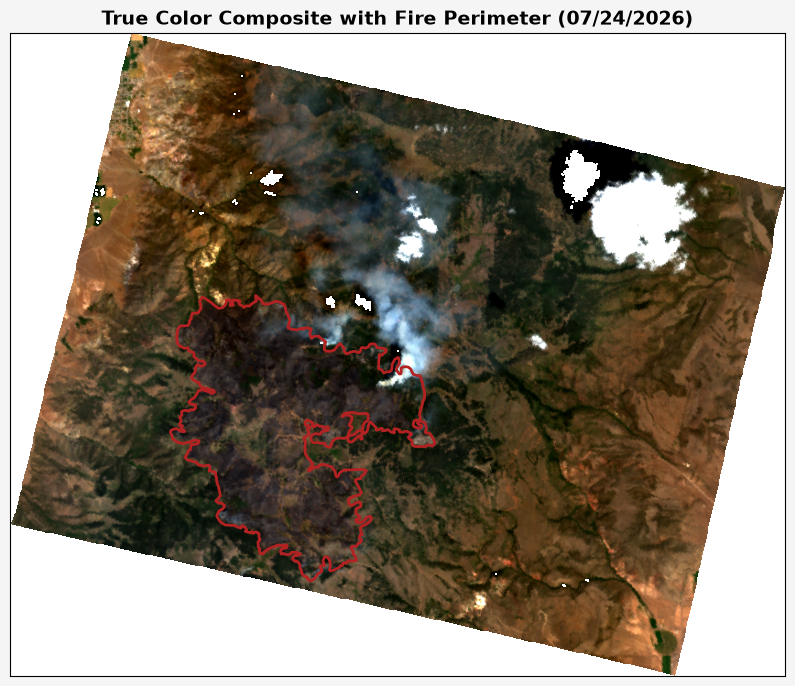

In [3]:
# Load the image
with h5py.File(sr_h5_path) as img:
    # Load surface reflectance dataset
    img_sr = img['/HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance']

    # Extract known red, green, and blue band indices from the stack (bands, height, width)
    rb = img_sr[54, :, :].astype(np.float32)
    gb = img_sr[34, :, :].astype(np.float32)
    bb = img_sr[16, :, :].astype(np.float32)

    # Extract georeferencing information
    geoinfo = tanager_utils.georeference_h5(img)

# Stack bands
rgb_img = np.dstack((rb, gb, bb))
# Handle nodata
rgb_img[rgb_img < 0] = np.nan

# Apply a percentile stretch for better visualization
p2, p98 = np.nanpercentile(rgb_img, (2, 98))
rgb_img_stretched = np.clip((rgb_img - p2) / (p98 - p2), 0, 1)

# Load the digitized fire perimeter
perimeter_path = Path(r"../data/gis/monroe_canyon_fire_perim_20250724.shp")
perim = gpd.read_file(perimeter_path).to_crs(geoinfo["crs"])

# Plot an RGB composite
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(rgb_img_stretched, 
          extent=[geoinfo["xmin"], geoinfo["xmax"], geoinfo["ymin"], geoinfo["ymax"],])
perim.plot(
    ax=ax, 
    facecolor="none", 
    edgecolor="firebrick", 
    linewidth=2)
plt.title("True Color Composite with Fire Perimeter (07/24/2026)", fontsize=14, fontweight='bold')
plt.gcf().set_facecolor('whitesmoke')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

### Create Cloud, Active Fire, and Smoke Mask

Use Tanager's out of the box cloud masking, as well as some additional masks customized for this analysis. 

We will create an active fire mask which removes pixels with a reflectance value > 1.0. Reflectance above 1.0 indicates these are a reflectance **source** and likely contain active fire.

Additionally, we will use the smoke mask generated in Notebook 1 to remove pixels that have high carbon dioxide content and likely contain significant haze and smoke.

The resulting image will contain clear pixels with no smoke or active fire, filtered to Tanager's good wavelengths for surface reflectance.

In [4]:
with h5py.File(sr_h5_path, "r") as img:
    # Extract surface reflectance dataset and index of good wavelengths for analysis
    sr_ds = img["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"]
    good = np.array(sr_ds.attrs["good_wavelengths"]).astype(bool)

    # Extract other wavelength properties to use later
    wavelengths = np.array(sr_ds.attrs["wavelengths"])[good]
    wavelengths_full = np.array(sr_ds.attrs["wavelengths"])
    fwhm = np.array(sr_ds.attrs["fwhm"])[good]

    # Load good bands
    good_idx = np.where(good)[0]
    sr = sr_ds[good_idx, :, :]
    sr = np.moveaxis(sr, 0, -1)   # (rows, cols, bands) keeps aligned with cloud masks

    # Convert fill values to NaN
    fill_value = sr_ds.attrs["_FillValue"]
    sr[sr == fill_value] = np.nan

    # Extract out of the box cloud and nodata masks
    cirrus = img["HDFEOS/GRIDS/HYP/Data Fields/beta_cirrus_mask"][:]
    cloud = img["HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask"][:]

    nodata = img["HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels"][:]

# NaN mask
nan_mask = (nodata.astype(np.uint8) & 1).astype(bool)

# Combine cloud masks using OR
cirrus_flag = (cirrus.astype(np.uint8) & 1).astype(bool)
cloud_flag = (cloud.astype(np.uint8) & 1).astype(bool)
cloud_or_cirrus = cirrus_flag | cloud_flag

# Create active fire mask using reflectance values > 1.0 across any band
pixel_max = np.nanmax(sr, axis=-1)
fire_mask = np.nan_to_num(pixel_max, nan=-np.inf) > 1.0

# Create smoke mask using output from notebook 1
smoke_path = Path(r"../data/plume_mask.npy")
smoke_array = np.load(smoke_path)
smoke_mask = (smoke_array.astype(np.uint8) & 1).astype(bool)

# Apply final mask
composite_mask = ~cloud_or_cirrus & ~fire_mask & ~smoke_mask & ~nan_mask
sr[~composite_mask, :] = np.nan

C:\Users\jtaylor\AppData\Local\Temp\ipykernel_29088\1761027075.py:35: RuntimeWarning: All-NaN slice encountered
  pixel_max = np.nanmax(sr, axis=-1)


### Clip the masked cube to the current fire perimeter
Finally, the masked cube will be clipped to the current fire perimeter, our Area of Interest (AOI) for spectral unmixing and burn severity analysis.

In [5]:
# Get AOI window from perimeter boundary using the same transform as the Tanager scene
win = from_bounds(*perim.total_bounds, transform=geoinfo["transform"]).round_offsets().round_lengths()

row0, row1 = win.row_off, win.row_off + win.height
col0, col1 = win.col_off, win.col_off + win.width

cube = sr[row0:row1, col0:col1, :]
cropped_transform = transform(win, geoinfo["transform"])

outside = geometry_mask(perim.geometry, out_shape=cube.shape[:2], transform=cropped_transform, invert=False, all_touched=False)
cube[outside, :] = np.nan

# Multiple Endmember Spectral Mixture Analysis (MESMA)
MESMA is an extension of Spectral Mixture Analysis (SMA) that models each pixel's reflectance spectrum as a combination of pure "endmember" spectra. The endmembers are weighted by their fractional cover within a given pixel, calculated by measuring the distance between the pixel and endmember's reflectance at the same wavelength. Standard SMA applies a fixed set of endmembers to an entire scene, which can struggle to capture natural variations across a landscape. MESMA, introduced by [Roberts et al. (1998)](https://doi.org/10.1016/S0034-4257(98)00037-6), allows the number and identity of endmembers to vary per pixel, testing many combinations of endmembers on the same pixel and choosing the best fit.

Hyperspectral imagery is a natural fit for MESMA. Where multispectral sensors sample reflectance in a few wide bands, sensors such as Tanager collect many contiguous narrow bands and therefore capture much more spectral variability even at the same spatial resolution. Wildfires produce a patchwork of char, bare soil, and remaining vegetation, varying within a few meters. Robust spectral unmixing can help land managers assess damage, evaluate hazard risks like burn scar flooding, and identify remaining refugia. Additionally, fractional cover outputs may be more interpretable than a unitless normalized burn ratio by informing the user of distributions of specific physical classes within the AOI.

This analysis uses portions of a spectral library created by the Joint Fire Science Program (JFSP) and hosted at https://www.frames.gov/assessing-burn-severity/spectral-library/overview. 
The sampled spectra represent pure component materials that exist in various mixtures within the AOI. The spectra used for this analysis were sampled on the ground post-fire in a mixed conifer forest in western Montana, USA. 
The major functional groups include green vegetation (gv), non-photosynthetic vegetation (npv), ash and char, and soil and rock. Eight spectra from each functional group were selected for this case study, to keep computational demands low.

### Configure reference spectral library


In [6]:
spectral_reference_dir = Path(r"../data/jfsp_spectral_library")
class_dirs = ["ash_char", "gv", "npv", "soil_rock"]
class_dict = {"ash_char" : "Ash/Char", "gv" : "Green Vegetation", "npv" : "Non-Photosynthetic Vegetation", "soil_rock" : "Soil/Rock"}

# Use a custom function to read .txt spectra files and resample them to match their responses to Tanager's good wavelengths
library, class_list, spectrum_names = tanager_utils.build_resampled_library(spectral_reference_dir, class_dirs, wavelengths, fwhm)

ash_char: 8 spectra loaded
gv: 8 spectra loaded
npv: 8 spectra loaded
soil_rock: 8 spectra loaded


### Run MESMA Models
After configuring the JFSP library as a MESMA input for Tanager wavelengths, the models can be configured. In this case, our (small) spectral library results in over 400 models being tested *per pixel*. 

Models will incorporate up to three endmembers and choose the best fit based on the lowest complexity and lowest root mean square error. The MESMA tools for python were originally developed by [Crabbé et al. (2020)](https://mesma.readthedocs.io/en/latest/) as a QGIS plugin.

In [7]:
class_list = np.array(class_list) # Ensure class_list is a NumPy array
models = MesmaModels()
models.setup(class_list)

look_up_table = models.return_look_up_table()
em_per_class = {c: np.where(class_list == c)[0].tolist() for c in set(class_list)}

mesma_mask = np.isnan(cube).any(axis=-1)
# MESMA wants 0 instead of NaN and dims reordered to put bands first
cube_for_mesma = np.moveaxis(np.nan_to_num(cube, nan=0.0), -1, 0)
no_data_idx = np.where(mesma_mask)

print(f"Total models to test per pixel: {models.total()}")

Total models to test per pixel: 416


In [8]:
# Run MESMA on the clipped, masked, and band-filtered Tanager scene
execute_kwargs = dict(
    image=cube_for_mesma,
    library=library,
    look_up_table=look_up_table,
    em_per_class=em_per_class,
    constraints=(-0.05, 1.05, 0.0, 0.8, 0.025, -9999, -9999),
    no_data_pixels=no_data_idx,
    residual_image=False,
)

model = MesmaCore(n_cores=4)

models_img, fractions_img, rmse_img, _ = model.execute(**execute_kwargs)

processing 2-EM models..3-EM models..

### Visualize Results
The resulting figure shows the fractional cover map of each class in the left column, ranging from 0 - 1. A value of 1 indicates that a pixel is completely composed of endmembers from that class. 

The right column contains the surface reflectance spectra for the purest pixel within the AOI from that class. Water vapor absorption areas are masked out.
* Ash/Char: steadily increasing reflectance from visible through SWIR, indicating blackened and carbonized material.
* Green Vegetation: low reflectance in visible from chlorophyll absorption, sharp red edge to a structured near infra-red plateau.
* Non-Photosynthetic Vegetation: similar to green vegetation but with a more muted red edge and lower plateau. This class consists of downed woody debris, dry grass, stumps, etc.
* Soil/Rock: Lowest reflectance overall, dipping at ~2000nm which indicates some types of mineral soils.

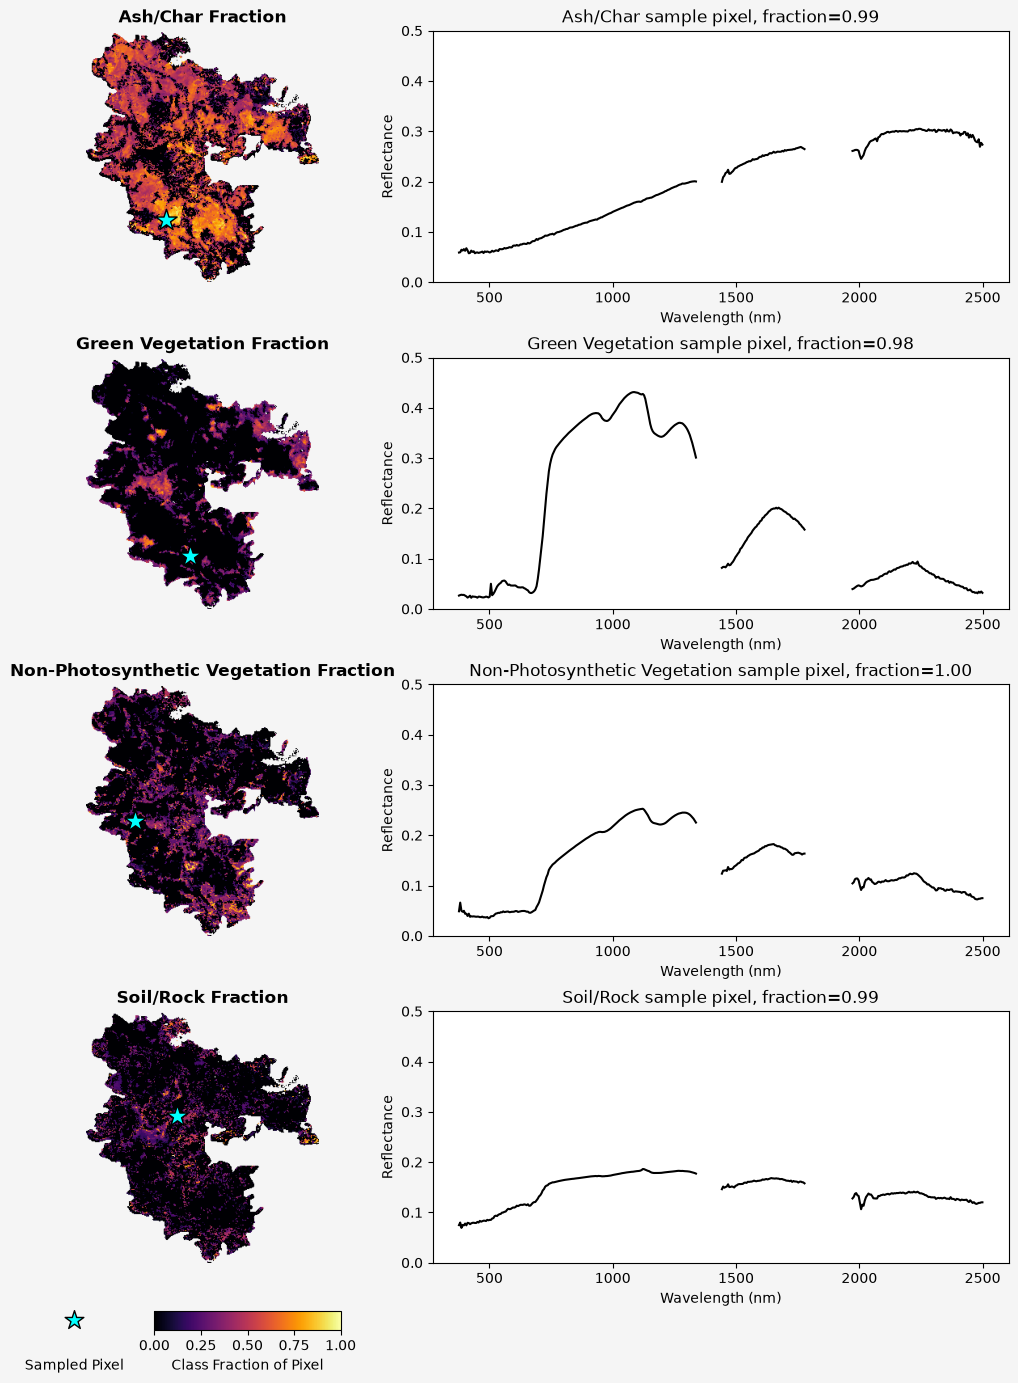

In [9]:
n_classes = len(class_dirs)
valid = ~mesma_mask  # True = usable pixel

# Pick a high pixel per class
sample_pixels = {}
for i, name in enumerate(class_dirs):
    frac_valid = np.where(valid, fractions_img[i], -np.inf)
    row, col = np.unravel_index(np.argmax(frac_valid), frac_valid.shape)
    sample_pixels[name] = (row, col)

# Figure dimensions
fig = plt.figure(figsize=(10, 4 * n_classes))
gs = gridspec.GridSpec(n_classes, 2, width_ratios=[1, 2], wspace=0.2, hspace=0.3, left=0.03, right=0.98)

# Main plot, loop through each class and plot the map and sampled reflectance
for i, name in enumerate(class_dirs):
    row, col = sample_pixels[name]

    # left: fraction map + marker
    ax_map = fig.add_subplot(gs[i, 0])
    im = ax_map.imshow(np.where(valid, fractions_img[i], np.nan),
                        cmap="inferno", vmin=0, vmax=1)
    ax_map.scatter(col, row, s=260, marker="*", facecolor="cyan",
                    edgecolor="black", linewidth=1)
    ax_map.set_title(f"{class_dict[name]} Fraction", fontsize=12, fontweight='bold')
    ax_map.axis("off")
    ax_map_last = ax_map # save reference to bottom map

    # right: spectral curve at that pixel
    ax_spec = fig.add_subplot(gs[i, 1])
    spectrum_full = np.full(wavelengths_full.shape, np.nan)
    spectrum_full[good] = cube[row, col, :]

    ax_spec.plot(wavelengths_full, spectrum_full, color="black", linewidth=1.5)
    ax_spec.set_ylim(0, 0.5)
    ax_spec.set_title(f"{class_dict[name]} sample pixel, "
                       f"fraction={fractions_img[i, row, col]:.2f}")
    ax_spec.set_xlabel("Wavelength (nm)")
    ax_spec.set_ylabel("Reflectance")

fig.canvas.draw()
pos = ax_map_last.get_position()  # bbox of bottom map in figure fraction coords

# Legend sizing
cbar_h = 0.012
row_gap = 0.03           
label_gap = 0.018        
star_w = 0.02             
star_cbar_gap = 0.07     
cbar_w = pos.width * 0.8

group_width = star_w + star_cbar_gap + cbar_w
group_x0 = pos.x0 + (pos.width - group_width) / 2  # center group under the map column
legend_y0 = pos.y0 - row_gap - cbar_h

# Star
star_ax = fig.add_axes([group_x0, legend_y0, star_w, cbar_h])
star_ax.set_xlim(0, 1)
star_ax.set_ylim(0, 1)
star_ax.scatter(0.5, 0.5, s=200, marker="*", facecolor="cyan",
                 edgecolor="black", linewidth=1, transform=star_ax.transAxes,
                 clip_on=False)
star_ax.axis("off")

# Colorbar
cbar_x0 = group_x0 + star_w + star_cbar_gap
cbar_ax = fig.add_axes([cbar_x0, legend_y0, cbar_w, cbar_h])
fig.colorbar(im, cax=cbar_ax, orientation="horizontal")

# Labels
label_y = legend_y0 - label_gap
fig.text(group_x0 + star_w / 2, label_y, "Sampled Pixel",
          ha="center", va="top", fontsize=10)
fig.text(cbar_x0 + cbar_w / 2, label_y, "Class Fraction of Pixel",
          ha="center", va="top", fontsize=10)

plt.gcf().set_facecolor('whitesmoke')
plt.show()

### Export fractional cover images

In [10]:
# Export each fractional cover map as band in a geotiff
n_classes, rows, cols = fractions_img.shape

mesma_results_path = Path(r"../data/images/mesma_results.tif")
with rasterio.open(
    mesma_results_path,
    "w",
    driver="GTiff",
    height=rows,
    width=cols,
    count=n_classes,
    dtype=fractions_img.dtype,
    crs=geoinfo["crs"],
    transform=cropped_transform,
    nodata=-9999,
) as file:
    for i, name in enumerate(class_dirs):
        band = np.where(valid, fractions_img[i], -9999).astype(fractions_img.dtype)
        file.write(band, i + 1)
        file.set_band_description(i + 1, class_dict[name])

# Conclusions
This notebook demonstrated how to download, georeference, and extract spectral information from an orthorectified Tanager surface reflectance image. After preparing the dataset, out of the box cloud masks were used alongside customized masks developed for the wildfire domain. 

The main analysis used MESMA to translate the 426 bands collected by Tanager into four meaningful groups of spectral signatures, mapped according to their fractional cover of each pixel:
* Ash and char show the distribution of burned areas where there is a lack of live or downed vegetation. Areas close to 1.0 fractional cover of ash and char are likely severely burned.
* Green vegetation shows the distribution of live vegetation within the fire perimeter. Areas with a strong fractional cover of green vegetation are likely unburned and contain pockets of intact habitat.
* Non-photosynthetic vegetation shows the distribution of bare materials like downed woody debris or standing trees with no canopy. It may indicate areas that have been moderately burned but not consumed, or areas of previous defoliation.
* Soil and rock show the distribution of barren ground or rock outcrops. Areas with strong fractional cover of this group may have been barren before the fire, or may have burned without creating a strong ash or char signature in this image.

The products created by this analysis are both scientifically valid for further analysis and understandable by stakeholders. One possible use case for Incident Managers could be using these products in conjunction with other GIS data like Digital Elevation Models (DEMs) and vector features like roadways to strategically assign resources to target areas at risk of post fire hazards for remediation. Another could be repeating this analysis with multiple Tanager images across a developing or recent wildfire to track how these signatures change across time and space.

Further study using this approach could include a greater diversity of spectral endmembers in the reference library as well ground-truth validation using other burn severity products. 

Increased availability of operational hyperspectral imagery from platforms such as a Tanager paired with access to high performance computing will make spectral extraction and analysis such as this demonstration even more approachable.